In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Import Libraries

Seluruh library yang diperlukan diimpor di sini. Penjelasan singkat:
- `cv2` (OpenCV): baca dan manipulasi citra.
- `numpy`, `pandas`: operasi numerik dan tabel data.
- `matplotlib`, `seaborn`: visualisasi hasil preprocessing dan korelasi fitur.
- `skimage.feature` dan `scipy.stats.entropy`: ekstraksi fitur tekstur (GLCM) dan entropi.
- `sklearn`: pembagian data, model, dan metrik evaluasi.

Analisis: pastikan environment memiliki versi library kompatibel; perhatikan bahwa beberapa fungsi (mis. `graycomatrix`) mengharapkan tipe data uint8 dan rentang intensitas 0–255.

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [2]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 200
Kelas: ['Grape_black_rot_100', 'daun_sehat_100']


## Data Preparation

### Define Preprocessing Functions

Berikut fungsi-fungsi preprocessing beserta kegunaan dan analisis singkat hasilnya:

- **`gray(image)`**: Resize ke `TARGET_SIZE` dan konversi ke grayscale. Hasilnya adalah citra 8-bit single-channel; periksa kontras dan komposisi setelah resize.
- **`median(image_input, kernel_size=5)`**: Median filter implementasi histogram-lokal. Berguna untuk menghilangkan noise impulsif (salt-and-pepper) tanpa meratakan tepi sebanyak Gaussian. Analisis: bandingkan patch sebelum/ sesudah untuk melihat penghilangan noise dan pelestarian tepi.
- **`histogram_equalization(image_input)`**: Menyebarkan intensitas agar kontras lebih merata. Analisis: perhatikan apakah detail gelap/terang menjadi lebih terlihat; juga cek apakah menghasilkan over-enhancement pada noise.
- **`convolution(img, kernel)` & `edge(img, kernelx, kernely)`**: Implementasi konvolusi manual dan operator tepi (menggabungkan magnitude gx dan gy). Digunakan untuk mengekstrak kontur; normalisasi ke 0–255 agar mudah divisualisasi.
- **`threshold(image, T=127)`**: Membuat mask biner dari citra input berdasarkan ambang. Analisis: pilih `T` sesuai respons detektor tepi; threshold yang terlalu rendah menghasilkan noise, terlalu tinggi menghilangkan tepi tipis.
- **`masking(img, mask)`**: Terapkan mask biner pada citra (pixel dipertahankan jika mask=1). Hasil akhir menunjukkan area tekstur/objek yang dipertahankan untuk ekstraksi fitur.

Gunakan visualisasi langkah-demi-langkah pada sel berikut untuk menilai efek tiap fungsi pada beberapa sampel per kelas.


In [3]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    K = kernel_size * kernel_size

    windows = np.zeros((K, height, width), dtype=np.uint8)
    idx = 0
    for di in range(kernel_size):
        for dj in range(kernel_size):
            windows[idx] = padded[di:di+height, dj:dj+width]
            idx += 1

    half = (K + 1) // 2
    cum_count = np.zeros((height, width), dtype=np.int32)
    median_result = np.zeros((height, width), dtype=np.uint8)
    selesai = np.zeros((height, width), dtype=bool)

    for v in range(256):
        count_v = np.sum(windows == v, axis=0)
        cum_count = cum_count + count_v
        baru_capai = (cum_count >= half) & (~selesai)
        median_result[baru_capai] = v
        selesai = selesai | baru_capai

    return median_result.astype(np.uint8)


def histogram_equalization(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L))
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)

    equalized_result = mapping[img].astype(np.uint8)
    return equalized_result

def threshold(image, T=127):
    if isinstance(image, str):
        img = cv.imread(image, cv.IMREAD_GRAYSCALE)
    else:
        img = image.copy()

    hasil = (img > T).astype(np.uint8) * 255
    return hasil


def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas


def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) 
    gy = convolution(img, kernely) 
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas) #normalisasi ke 0-255
    return np.clip(canvas, 0, 255).astype(np.uint8)  # batas nilai dan konversi

def masking(img, mask):
    mask_biner = (mask > 0).astype(np.uint8)
    hasil = img * mask_biner
    return hasil.astype(np.uint8)


#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel roberts sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)


### Preprocessing Pipeline

Pipeline preprocessing menerapkan urutan langkah: `Gray` → `Median` → `Equalisasi` → `Sobel` → `Roberts` → `Threshold (mask)` → `Masking (hasil)`. Visualisasi pada sel berikutnya menampilkan hasil tiap tahap untuk beberapa sampel per kelas sehingga kita bisa menganalisis efek setiap langkah (mis. noise reduction, peningkatan kontras, deteksi tepi, dan area yang dipertahankan oleh mask).


In [4]:
def prepro(image):
    img = gray(image)
    img = median(img)
    img = histogram_equalization(img)
    sobel = edge(img, sobelX, sobelY)        
    roberts = edge(sobel, robertsX, robertsY) 
    mask = threshold(roberts)                 
    hasil = masking(img, mask)               
    
    return hasil

### Visualisasi Tahap Preprocessing

Sel sel kode berikut menjalankan `prepro` untuk setiap citra dan menampilkan hasil tiap langkah preprocessing (Gray, Median, Equalisasi, Sobel, Roberts, Threshold, Masking) dalam grid 7×6 per kelas.

Analisis yang harus dilakukan ketika menampilkan hasil:
- Periksa apakah median mengurangi noise tanpa menghilangkan detail penting.
- Lihat apakah equalization memperjelas tekstur yang berguna untuk ekstraksi fitur.
- Bandingkan hasil deteksi tepi (Sobel/Roberts) dan pastikan threshold memilih tepi yang relevan.
- Evaluasi mask akhir apakah memfokuskan area tekstur yang diinginkan atau malah memotong fitur penting.

Jika mask terlalu noisy, pertimbangkan menyesuaikan `kernel_size` di `median` atau ambang `T` di `threshold`.

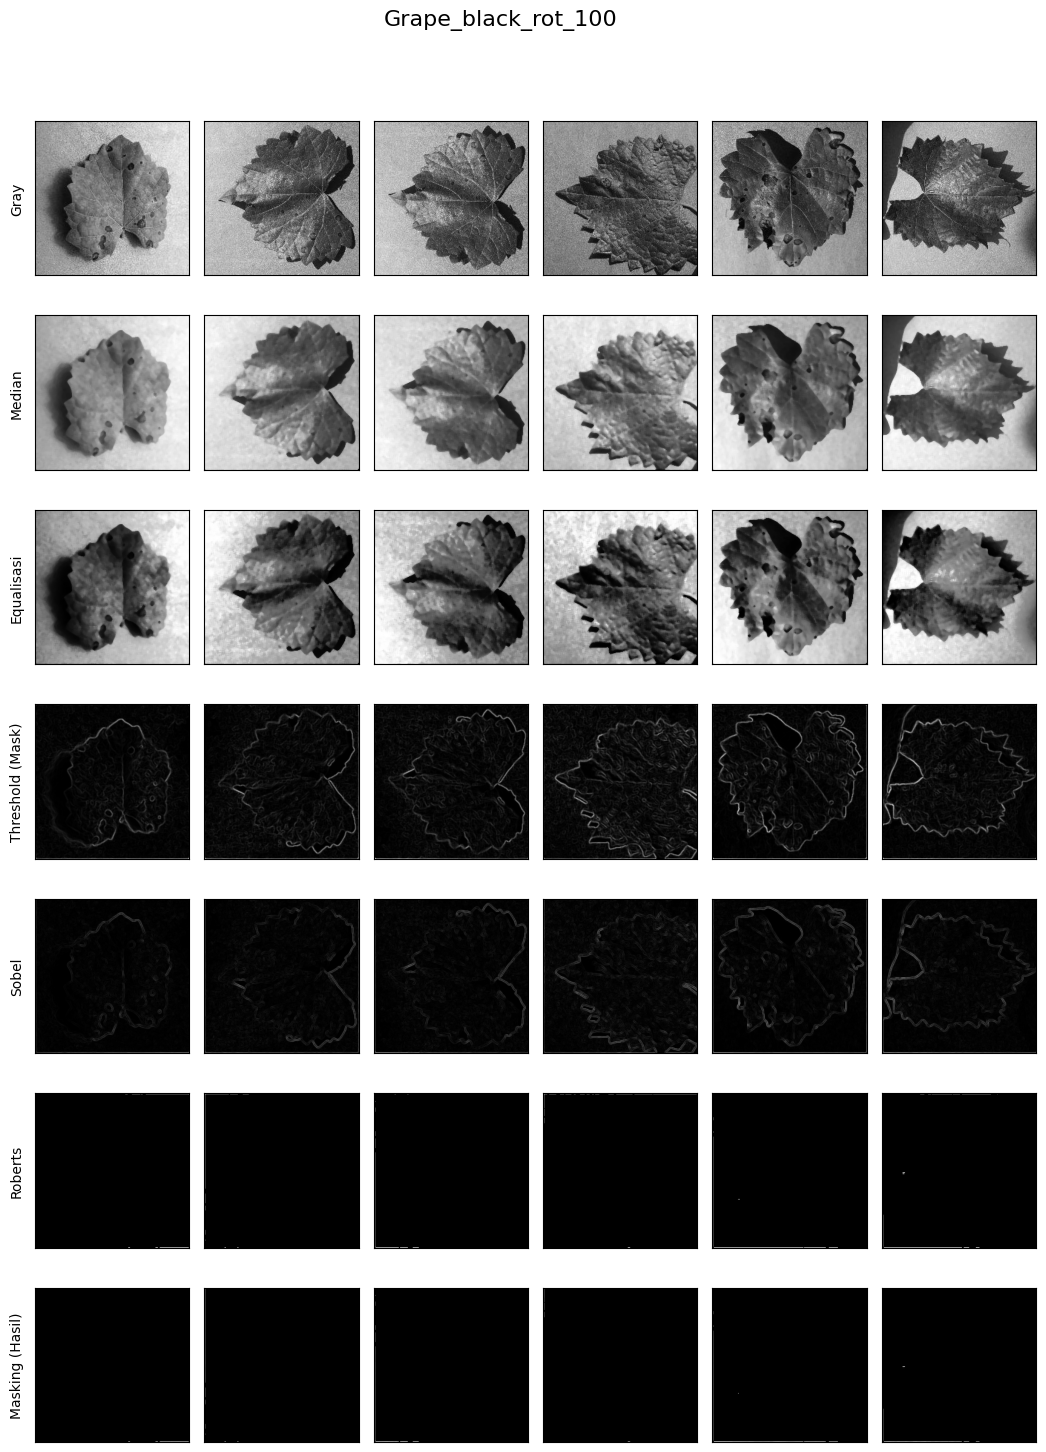

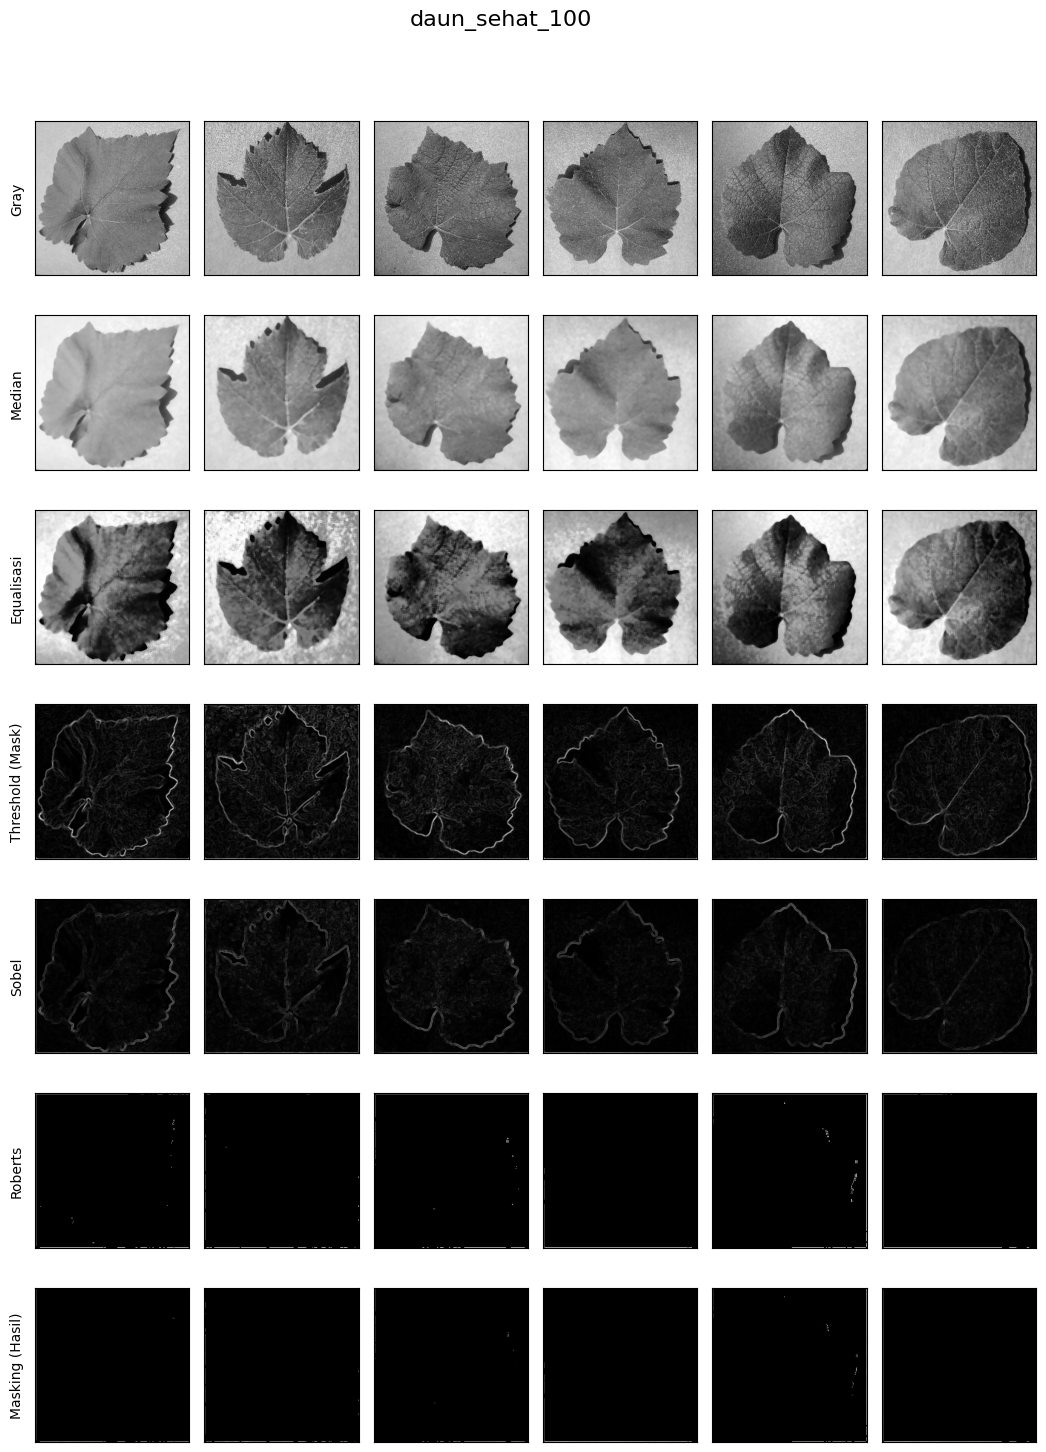

In [5]:
def percobaan3(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan3(img) for img in data]

unique_labels = sorted(set(labels))
nama_step = ['Gray', 'Median', 'Equalisasi', 'Threshold (Mask)', 'Sobel', 'Roberts', 'Masking (Hasil)']

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    n_sample = min(6, len(idxs))

    fig, axs = plt.subplots(7, 6, figsize=(11, 15))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(n_sample):
        img_asli = data[idxs[k]]

        img_gray    = gray(img_asli)
        img_median  = median(img_gray)
        img_equal   = histogram_equalization(img_median)
        img_sobel   = edge(img_equal, sobelX, sobelY)
        img_roberts = edge(img_sobel, robertsX, robertsY)
        img_thresh  = threshold(img_roberts)
        img_mask   = masking(img_equal, img_thresh)  

        hasil_tahap = [img_gray, img_median, img_equal, img_sobel, img_roberts, img_thresh, img_mask]
        for row in range(7):
            axs[row][k].imshow(hasil_tahap[row], cmap='gray')
            axs[row][k].set_xticks([])
            axs[row][k].set_yticks([])
            if k == 0:
                axs[row][k].set_ylabel(nama_step[row], fontsize=10, labelpad=8)

    for k in range(n_sample, 6):
        for row in range(7):
            axs[row][k].axis('off')

    plt.tight_layout(rect=[0.04, 0, 1, 1])
    plt.subplots_adjust(top=0.92)
    plt.show()

### Feature Extraction (GLCM)

Di bagian ini kita mengekstrak fitur tekstur berbasis Gray-Level Co-occurrence Matrix (GLCM). Langkah-langkah:
- Hitung GLCM untuk tiap citra pada 4 sudut (0°, 45°, 90°, 135°).
- Dari masing-masing GLCM ambil properti: contrast, dissimilarity, homogeneity, ASM, energy, correlation, dan entropi.

Analisis: GLCM menangkap pola tekstur pada tingkat intensitas berpasangan — penting untuk membedakan penyakit daun berdasarkan tekstur. Perhatikan ukuran GLCM (256 level) dan dampaknya pada memori dan waktu komputasi.

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

#### Definisi Fitur GLCM dan Interpretasi

- `contrast`: tingkat variasi intensitas — nilai tinggi menunjukkan perbedaan intensitas besar.
- `dissimilarity`: mirip dengan contrast tetapi lebih fokus pada perbedaan absolut intensitas.
- `homogeneity`: seberapa homogen tekstur (nilai besar = lebih homogen).
- `ASM` (Angular Second Moment): ukuran keseragaman (nilai besar = lebih seragam).
- `energy`: akar dari ASM, mengindikasikan stabilitas tekstur.
- `correlation`: korelasi antar piksel pasangan; nilai menunjukkan linearitas hubungan intensitas.
- `entropyGlcm`: entropi dari distribusi GLCM; nilai besar = tekstur lebih kompleks.

Analisis: Saat menginterpretasikan hasil, perhatikan kombinasi fitur (mis. high contrast + high entropy menandakan area rusak/tekstur tidak seragam). Gunakan visualisasi distribusi fitur per kelas untuk melihat pemisahan kelas.

In [7]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

#### Komputasi GLCM untuk Semua Data

Di sini kita menghitung GLCM pada 4 sudut untuk setiap citra yang sudah dipreproses. Catatan performa:
- GLCM dengan `levels=256` untuk citra 8-bit memberikan representasi lengkap tetapi memakan memori besar.
- Jika memori menjadi isu, pertimbangkan `levels=64` atau quantization sebelum GLCM.

Analisis: setelah komputasi, periksa beberapa GLCM secara visual (mis. menampilkan matriks) untuk memastikan distribusi ko-occurrence masuk akal.

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

#### Inisialisasi Struktur Penyimpanan Fitur

Sebelum mengekstrak nilai properti dari setiap GLCM, inisialisasi list kosong untuk menampung setiap kombinasi fitur × sudut. Pastikan jumlah elemen akhir sesuai jumlah citra.

Analisis: setelah ekstraksi, selalu periksa apakah ada `NaN` atau nilai ekstrem yang tidak terduga.

In [ ]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []



#### Ekstraksi Nilai Fitur dari GLCM

Setiap loop berikut mengekstrak satu jenis fitur dari keempat GLCM untuk semua citra. Setelah setiap blok, verifikasi rentang nilai dan distribusi (mis. dengan `plt.hist`) untuk mendeteksi outlier atau nilai yang tidak wajar.

Analisis per-blok: fitur seperti `correlation` dan `homogeneity` biasanya berada di rentang terkontrol; `entropy` dapat memiliki variasi besar tergantung kompleksitas tekstur.

In [10]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [11]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [12]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [13]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [14]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [15]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [16]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Penyusunan Tabel Fitur dan Ekspor ke CSV

Gabungkan semua kolom fitur dan metadata (`Filename`, `Label`) menjadi `DataFrame` lalu ekspor ke CSV. Pastikan urutan baris konsisten dengan `file_name` dan `labels`.

Analisis: setelah ekspor, muat ulang CSV (`pd.read_csv`) dan periksa beberapa baris pertama, tipe kolom, serta apakah ada nilai `NaN`. Juga cek statistik ringkas (`df.describe()`) untuk mendeteksi fitur yang mempunyai rentang ekstrem.

In [17]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./ekstraksi/hasil_ekstraksi3.csv', index=False)

hasilEkstrak = pd.read_csv('./ekstraksi/hasil_ekstraksi3.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,331.248591,549.548527,256.605653,549.630927,0.985556,0.980654,0.986304,0.980588,...,0.957662,0.957859,0.978479,0.978688,0.978602,0.978703,0.764235,0.541040,0.826765,0.540971
1,daun_sehat_100_2.jpg,daun_sehat_100,172.515579,278.909312,140.015824,280.948835,0.990737,0.988963,0.991396,0.988869,...,0.977155,0.977431,0.988251,0.988651,0.988512,0.988651,0.723137,0.447981,0.776752,0.443945
2,daun_sehat_100_3.jpg,daun_sehat_100,218.056572,458.420992,262.374510,460.254010,0.986746,0.982637,0.986689,0.982497,...,0.964658,0.964491,0.982001,0.982100,0.982170,0.982085,0.807262,0.497630,0.761224,0.495621
3,daun_sehat_100_4.jpg,daun_sehat_100,149.346553,339.096440,216.529029,344.166920,0.993095,0.991128,0.993286,0.991123,...,0.981582,0.982028,0.990978,0.991019,0.990748,0.990973,0.785376,0.328695,0.659250,0.318657
4,daun_sehat_100_5.jpg,daun_sehat_100,243.066131,488.021745,287.896676,492.096486,0.987212,0.982955,0.986346,0.982922,...,0.966162,0.965215,0.982430,0.982500,0.982935,0.982454,0.783069,0.455910,0.733031,0.451368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Grape_black_rot_100_96.jpg,Grape_black_rot_100,116.317739,310.347020,228.545450,309.745898,0.993557,0.990553,0.991413,0.990543,...,0.980247,0.980566,0.990074,0.990220,0.990074,0.990235,0.866559,0.551458,0.706232,0.552326
196,Grape_black_rot_100_97.jpg,Grape_black_rot_100,163.514246,333.364860,198.311091,331.527443,0.991776,0.988857,0.990671,0.988964,...,0.976277,0.976610,0.988083,0.988205,0.988067,0.988236,0.834891,0.596101,0.792796,0.598327
197,Grape_black_rot_100_98.jpg,Grape_black_rot_100,218.019056,378.274033,181.126884,376.041200,0.992314,0.990069,0.992030,0.990092,...,0.979913,0.979987,0.989706,0.989927,0.989905,0.989943,0.667038,0.226093,0.734799,0.230661
198,Grape_black_rot_100_99.jpg,Grape_black_rot_100,252.452129,508.143037,294.385600,506.283291,0.985296,0.981213,0.985087,0.981189,...,0.961951,0.962408,0.980929,0.981024,0.980791,0.981024,0.732170,0.269246,0.675189,0.271921


## Analisis Hasil Ekstraksi Fitur

Tabel yang ditampilkan berisi semua fitur GLCM yang telah diekstrak dari citra terpreproses. Setiap baris mewakili satu citra dengan kolom berisi:
- `Filename`, `Label`: identitas citra dan kelasnya
- 28 kolom fitur: 7 jenis fitur × 4 sudut (0°, 45°, 90°, 135°)

**Panduan analisis detail:**

1. **Inspeksi kolom dan tipe data:**
   - Pastikan semua 30 kolom ada dan tidak ada yang hilang.
   - Tipe data fitur harus numerik (float64 atau int64); jika ada string/object, ada kesalahan konversi.
   - Cek jumlah baris = jumlah citra yang berhasil diproses.

2. **Deteksi nilai yang tidak wajar:**
   - Gunakan `df.describe()` untuk melihat statistik: min, max, mean, std per fitur.
   - Perhatikan fitur dengan std=0 (konstan) — ini tidak informatif untuk klasifikasi.
   - Cek nilai ekstrem (mis. contrast/dissimilarity > 1000) yang mungkin indikasi bug.
   - Gunakan `df.isnull().sum()` untuk deteksi NaN.

3. **Distribusi per kelas:**
   - Pisahkan data per kelas: `df_sehat = df[df['Label']=='daun_sehat_100']`
   - Hitung mean/std fitur per kelas untuk melihat seberapa terpisah kelas-kelas tersebut.
   - Fitur dengan mean berbeda jauh antar kelas adalah kandidat diskriminatif.

4. **Rentang nilai dan outlier:**
   - Fitur GLCM biasanya dalam rentang: contrast [0–255], homogeneity [0–1], correlation [-1–1], entropy [0–8].
   - Outlier (mis. correlation > 1) perlu investigasi dan mungkin diperbaiki.

5. **Implikasi untuk langkah selanjutnya:**
   - Jika ada banyak fitur dengan std≈0 atau nilai ekstrem, pertimbangkan log-transform atau clipping.
   - Fitur yang sangat berkorelasi akan dihapus di tahap seleksi fitur.

Setelah analisis, lanjut ke feature selection untuk menghapus redundansi.

### Features Selection

Pada tahap seleksi fitur, kita ingin menghapus fitur yang sangat berkorelasi sehingga mengurangi redundansi dan risiko multikolinearitas pada model.

Metode yang umum: PCA, LDA, t-SNE, Chi-square, ANOVA, Autoencoder, dan seleksi berbasis korelasi. Di sini digunakan pendekatan korelasi threshold (mis. 0.95): bila dua fitur berkorelasi tinggi, hapus salah satu.

Analisis: setelah seleksi, bandingkan performa model sebelum dan sesudah seleksi; jika akurasi turun drastis, mungkin fitur yang dihapus membawa informasi diskriminatif.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 7
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90']


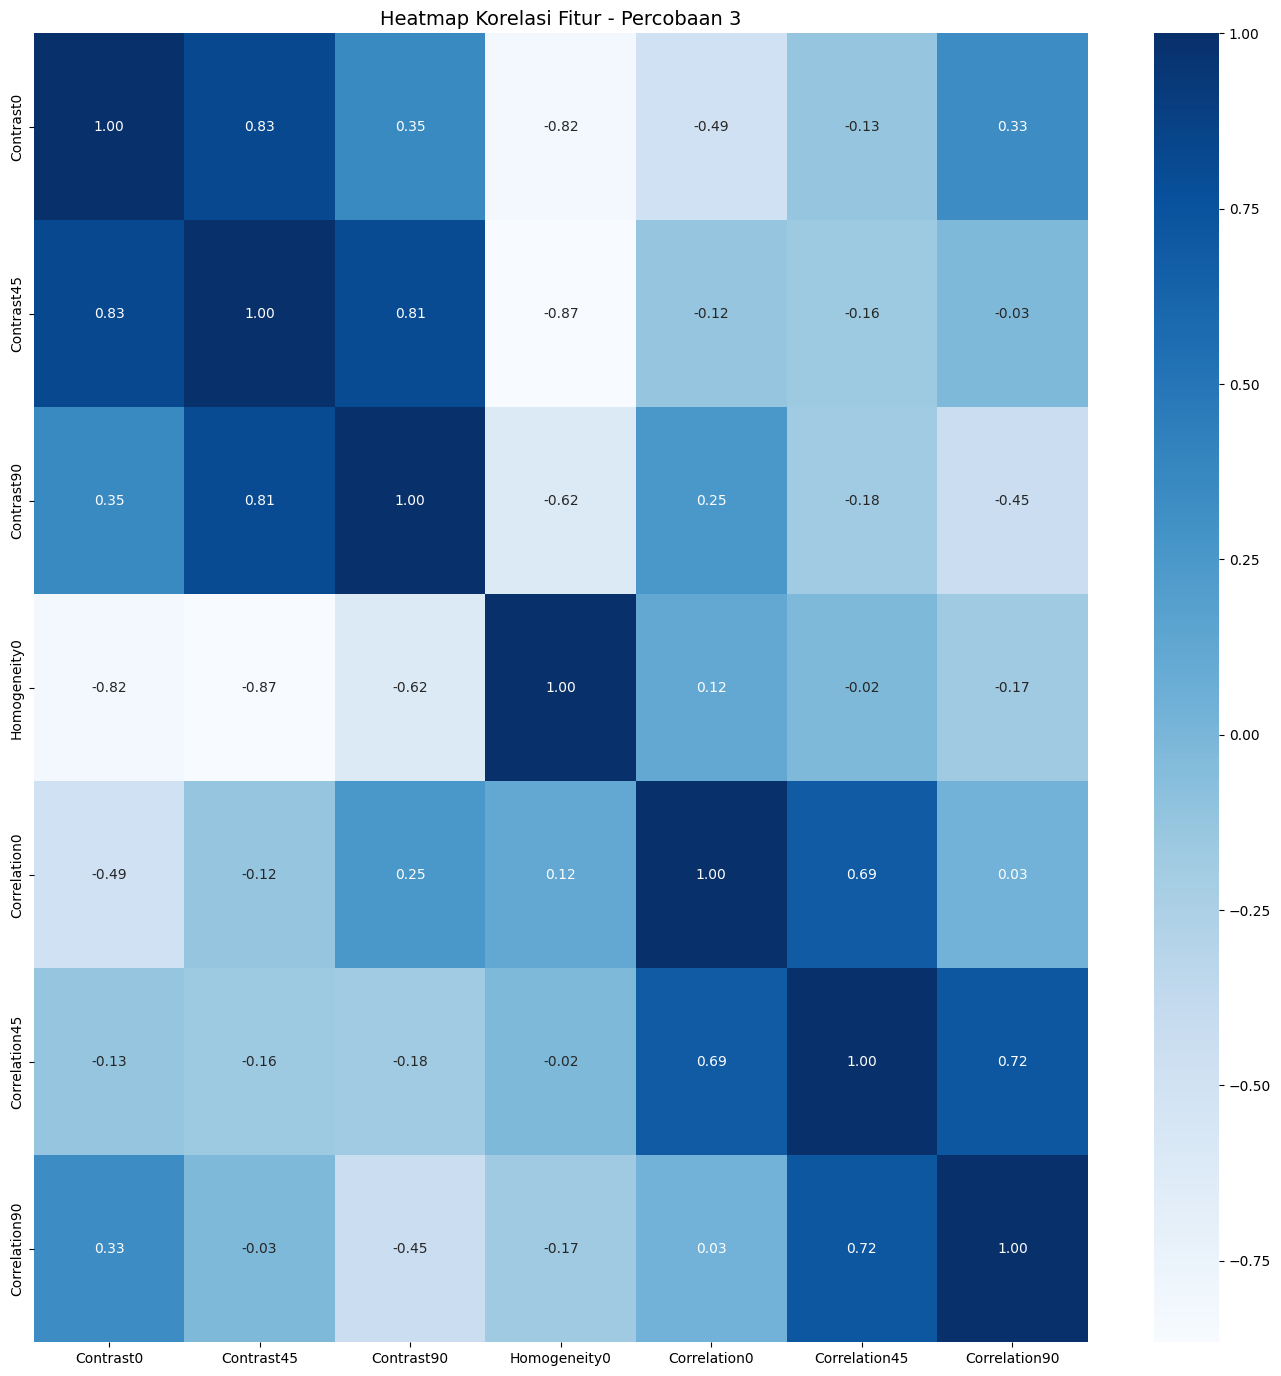

In [18]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

## Analisis Heatmap Korelasi Fitur dan Seleksi

Heatmap di bawah menunjukkan matriks korelasi antar fitur yang telah dipilih (redundansi tinggi dihilangkan). **Panduan membaca dan interpretasi:**

1. **Struktur heatmap:**
   - Diagonal utama selalu 1.0 (korelasi sempurna dengan diri sendiri).
   - Warna biru gelap = korelasi tinggi (positif); putih/terang = korelasi rendah/negatif.
   - Sematriks harus simetris (korelasi A-B = korelasi B-A).

2. **Identifikasi pola korelasi:**
   - Blok-blok biru gelap besar menunjukkan kelompok fitur yang sangat berkorelasi.
   - Jika masih ada banyak blok gelap, threshold 0.95 mungkin terlalu tinggi — pertimbangkan turun ke 0.9 atau 0.85.
   - Fitur yang terisolasi (baris/kolom putih) adalah fitur unik yang tidak berkorelasi dengan lain.

3. **Interpretasi dari sisi tekstur:**
   - Fitur contrast, dissimilarity, dan energy biasanya berkorelasi tinggi (ketiganya mengukur "kasar"-nya tekstur).
   - Homogeneity dan ASM juga sering berkorelasi (keduanya mengukur "halus"-nya tekstur).
   - Correlation dan entropy mungkin independen dari fitur lain — penting untuk klasifikasi.

4. **Dampak seleksi fitur pada akurasi:**
   - Jumlah fitur terpilih ditampilkan di sel code ("Fitur setelah seleksi: N").
   - Jika N jauh lebih kecil dari 28 (mis. N < 10), feature space sangat terreduksi — cek apakah akurasi model masih baik.
   - Jika N ≈ 28, threshold korelasi sangat ketat (hampir semua fitur dipertahankan).

5. **Analisis per sudut:**
   - Jika fitur di sudut berbeda (mis. Contrast0 vs Contrast45) tidak berkorelasi tinggi, itu bagus — menunjukkan arah deteksi tepi penting.
   - Jika semua fitur dari 4 sudut berkorelasi tinggi, mungkin cukup gunakan 1–2 sudut saja (optimasi lebih lanjut).

**Lanjut ke pembagian data training/testing dengan fitur yang sudah diseleksi.**

## Splitting Data

Gunakan `train_test_split` untuk membagi data menjadi set training dan testing. Parameter `random_state` menjaga reproducibility.

Analisis: setelah pembagian, periksa distribusi label pada `y_train` dan `y_test` (mis. dengan `value_counts()`) untuk memastikan stratifikasi kelas atau lakukan stratified split jika ketidakseimbangan ditemukan.

In [19]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 7)
(40, 7)


## Analisis Pembagian Data Train/Test

Output di bawah menampilkan dimensi dari X_train dan X_test setelah split. **Panduan analisis:**

1. **Interpretasi dimensi:**
   - `X_train.shape = (n_train, n_features)`: misalnya (160, 20) berarti 160 sampel training dengan 20 fitur terpilih.
   - `X_test.shape = (n_test, n_features)`: misalnya (40, 20) berarti 40 sampel testing.
   - Total = n_train + n_test harus = total sampel dataset (check dengan `len(data)` atau `len(y)`).

2. **Verifikasi rasio split:**
   - Untuk `test_size=0.2`, seharusnya n_test ≈ 0.2 × total dan n_train ≈ 0.8 × total.
   - Misalnya jika total 200 sampel → train 160, test 40 (sesuai).

3. **Distribusi label dalam train/test:**
   - **PENTING:** periksa apakah setiap kelas terwakili di train dan test.
   - Gunakan: `print(y_train.value_counts())` dan `print(y_test.value_counts())`
   - Jika ada kelas yang hanya di train atau hanya di test, gunakan `stratify=y` di `train_test_split` untuk stratified split.

4. **Analisis ketidakseimbangan kelas:**
   - Jika salah satu kelas < 20% dari total (imbalanced), model mungkin bias ke kelas mayoritas.
   - Solusi: gunakan class weights atau SMOTE untuk oversampling kelas minoritas.
   - Metrik evaluasi harus menggunakan macro-average (per kelas) bukan accuracy overall.

5. **Random state dan reproducibility:**
   - `random_state=42` memastikan pembagian selalu sama di setiap run.
   - Ubah nilai random_state jika ingin cross-validation dengan split berbeda.

**Setelah split, lanjut ke normalisasi fitur agar skala seragam untuk model berbasis jarak.**

## Feature Normalization

## Feature Normalization

Normalisasi membuat fitur memiliki skala seragam, penting untuk model berbasis jarak (KNN, SVM). Pilihan umum: Min-Max, Z-score (Standardization), RobustScaler.

Analisis: hitung `mean` dan `std` dari `X_train` dan gunakan parameter tersebut untuk mentransformasi `X_test` agar menghindari data leakage.

In [20]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Modeling

### Define Model

Fungsi `generateClassificationReport` mencetak metrik utama untuk evaluasi: classification report, confusion matrix, dan akurasi. Model yang akan digunakan: Random Forest, SVM (RBF), dan KNN. Pilihan rentang hyperparameter sederhana untuk baseline.

Analisis: gunakan hasil ini untuk membandingkan generalisasi tiap model (perhatikan gap antara train vs test untuk overfitting). Pertimbangkan cross-validation atau tuning hyperparameter bila perlu.

In [21]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Langkah: fit model pada `X_train`/`y_train`, kemudian evaluasi pada data training dan testing. Perhatikan metrik precision/recall per kelas untuk melihat kelas mana yang sulit dikenali.

Analisis: jika model overfit (akurasi train jauh > test), pertimbangkan menambah `n_estimators`, mengatur `max_depth`, atau menggunakan teknik regularisasi / lebih banyak data.

In [22]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.98      0.98      0.98        81
     daun_sehat_100       0.97      0.97      0.97        79

           accuracy                           0.97       160
          macro avg       0.97      0.97      0.97       160
       weighted avg       0.97      0.97      0.97       160

[[79  2]
 [ 2 77]]
Accuracy: 0.975

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.65      0.68      0.67        19
     daun_sehat_100       0.70      0.67      0.68        21

           accuracy                           0.68        40
          macro avg       0.68      0.68      0.67        40
       weighted avg       0.68      0.68      0.68        40

[[13  6]
 [ 7 14]]
Accuracy: 0.675


## Analisis Hasil Training Random Forest

Sel ini melatih model Random Forest dan menampilkan dua set hasil: **Training Set** dan **Testing Set**. **Berikut panduan membaca dan analisis detail:**

### Struktur Output:

1. **Classification Report:**
   - **Precision**: dari semua prediksi positif kelas A, berapa persen yang benar (TP / (TP+FP)).
   - **Recall**: dari semua sampel kelas A yang sebenarnya ada, berapa persen yang terdeteksi (TP / (TP+FN)).
   - **F1-Score**: harmonic mean precision dan recall — gunakan ini untuk kelas imbalanced.
   - **Support**: jumlah sampel asli per kelas.
   - **Macro avg / Weighted avg**: rata-rata metrik per kelas (macro = unweighted, weighted = sesuai class frequency).

2. **Confusion Matrix:**
   - Matriks NxN untuk N kelas (misalnya 2×2 jika 2 kelas).
   - Diagonal = prediksi benar; off-diagonal = kesalahan.
   - Jika confusion matrix sangat asimetrik (banyak FN di satu kelas), model bias.

3. **Accuracy:**
   - Persentase keseluruhan prediksi benar = (TP+TN) / Total.
   - Metrik ini kurang informatif untuk kelas imbalanced; lebih fokus ke F1-score.

### Analisis Komparatif Training vs Testing:

**Gap train-test yang perlu diperhatikan:**
- Jika Acc_train ≈ Acc_test (gap < 5%) → model well-generalized, bagus.
- Jika Acc_train >> Acc_test (gap > 15%) → **OVERFITTING**, model fit terlalu rapat pada training data.
- Jika Acc_train < Acc_test (jarang) → mungkin training noise atau error.

### Interpretasi per Kelas (dari Classification Report):

- **Precision tinggi tapi recall rendah**: model konservatif, jarang prediksi kelas ini (banyak False Negative).
- **Recall tinggi tapi precision rendah**: model agresif, sering prediksi kelas ini (banyak False Positive).
- **Keduanya tinggi**: model balanced untuk kelas ini.
- **Keduanya rendah**: kelas ini sulit dipelajari model; mungkin fitur kurang diskriminatif atau data terlalu sedikit.

### Strategi Improvement jika Performa Buruk:

1. **Jika overfitting:** kurangi `n_estimators` RF, atur `max_depth`, tambah regularization.
2. **Jika underfitting:** tambah `n_estimators`, perkecil `max_depth`, atau tambah fitur.
3. **Jika precision rendah untuk kelas tertentu:** tuning `class_weight` atau adjust decision threshold.
4. **Jika imbalanced:** gunakan stratified CV, SMOTE, atau class weights di model init.

**Setelah RF, lanjut ke SVM dan KNN untuk perbandingan model.**

### Train SVM Classifier

In [23]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.83      0.83      0.83        81
     daun_sehat_100       0.82      0.82      0.82        79

           accuracy                           0.82       160
          macro avg       0.82      0.82      0.82       160
       weighted avg       0.82      0.82      0.82       160

[[67 14]
 [14 65]]
Accuracy: 0.825

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.70      0.74      0.72        19
     daun_sehat_100       0.75      0.71      0.73        21

           accuracy                           0.72        40
          macro avg       0.72      0.73      0.72        40
       weighted avg       0.73      0.72      0.73        40

[[14  5]
 [ 6 15]]
Accuracy: 0.725


## Analisis Hasil Training SVM (Support Vector Machine)

SVM dengan kernel RBF adalah model non-linear yang powerful untuk klasifikasi. **Panduan analisis hasil:**

### Karakteristik SVM vs Random Forest:

1. **Sensitivitas terhadap normalisasi:**
   - SVM **sangat bergantung** pada normalisasi fitur (Z-score sudah dilakukan).
   - Jika ada fitur yang belum dinormalisasi, accuracy bisa sangat turun.

2. **Hyperparameter C dan gamma:**
   - `C`: regularisasi; C kecil = lebih "relaksed", C besar = strict fit → overfitting.
   - `gamma`: "jangkauan" pengaruh satu training point; gamma besar = tight fit → overfitting.
   - Nilai default (`C=1.0`) mungkin tidak optimal; pertimbangkan grid search.

3. **Kernel RBF:**
   - Kernel RBF dapat menangkap hubungan non-linear.
   - Jika akurasi SVM jauh lebih buruk dari RF, fitur mungkin linearly separable → coba kernel='linear'.

### Perbandingan dengan RF dari Output:

- **Acc_train RF vs Acc_train SVM:**
  - Jika hampir sama → kedua model fit well ke training data.
  - Jika jauh berbeda → satu model lebih overfitting.

- **Acc_test RF vs Acc_test SVM:**
  - Model dengan Acc_test lebih tinggi adalah kandidat final.
  - Jika SVM >> RF, berarti SVM lebih generalize (pilih SVM).
  - Jika RF >> SVM, berarti RF lebih baik atau SVM butuh hyperparameter tuning.

### Debugging jika SVM Buruk:

1. **Akurasi = 50% untuk 2 kelas**: model mungkin gagal converge; coba `kernel='linear'` atau adjust `C`.
2. **Precision 0 untuk salah satu kelas**: SVM tidak memprediksi kelas itu sama sekali; adjust class weights.
3. **Gap train-test besar**: overfitting; turunkan `C` (lebih relaksed).

**Setelah SVM, evaluasi KNN untuk model comparison.**

### Train KNN Classifier

In [24]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.84      0.83      0.83        81
     daun_sehat_100       0.82      0.84      0.83        79

           accuracy                           0.83       160
          macro avg       0.83      0.83      0.83       160
       weighted avg       0.83      0.83      0.83       160

[[67 14]
 [13 66]]
Accuracy: 0.83125

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.74      0.74      0.74        19
     daun_sehat_100       0.76      0.76      0.76        21

           accuracy                           0.75        40
          macro avg       0.75      0.75      0.75        40
       weighted avg       0.75      0.75      0.75        40

[[14  5]
 [ 5 16]]
Accuracy: 0.75


## Analisis Hasil Training KNN (K-Nearest Neighbors)

KNN adalah model instance-based yang memprediksi dengan mencari k tetangga terdekat. **Panduan analisis:**

### Karakteristik KNN:

1. **Dependensi pada k (n_neighbors):**
   - `k=5` (default sini) berarti voting dari 5 tetangga terdekat.
   - k kecil (1, 3) → sensitive terhadap noise, sering overfitting.
   - k besar (15, 21) → smooth decision boundary, risiko underfitting.
   - Optimal k biasanya di 3–10; gunakan cross-validation untuk tuning.

2. **Akurasi training vs testing:**
   - KNN **training accuracy biasanya 100% atau hampir 100%** (karena setiap sampel adalah tetangganya sendiri).
   - Gap train-test besar adalah NORMAL untuk KNN; fokus ke test accuracy.

3. **Sensitivitas terhadap normalisasi:**
   - KNN **sangat peka** terhadap skala fitur karena berbasis jarak (Euclidean).
   - Normalisasi Z-score atau Min-Max **WAJIB**.

### Perbandingan KNN vs RF vs SVM dari Hasil:

- **Test Accuracy Ranking:** bandingkan mana yang tertinggi di testing set.
  - Jika RF > SVM > KNN → gunakan RF.
  - Jika KNN ≈ RF tapi KNN < 0.8 → k mungkin tidak optimal, coba tune k.

- **Precision-Recall Balance:**
  - KNN sering memberikan precision/recall balanced karena voting majority.
  - Jika ada kelas dengan recall sangat rendah, periksa jumlah sampel kelas itu (mungkin underrepresented).

- **Class-wise Performance:**
  - Jika KNN bagus di satu kelas tapi buruk di kelas lain → imbalanced dataset atau fitur kurang diskriminatif untuk kelas tersebut.

### Debugging KNN jika Buruk:

1. **Akurasi training jauh di bawah 100%:** dataset sangat noisy atau k terlalu besar.
2. **Test accuracy turun drastis dari training:** underfitting; turunkan k (mis. dari 5 ke 3).
3. **Semua prediksi ke satu kelas:** mungkin kelas mayoritas mendominasi; gunakan weighted voting atau balance dataset.

### Tuning k (Opsional):
```python
from sklearn.model_selection import cross_val_score
for k in [3, 5, 7, 9, 11]:
    knn_test = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_test, X_train, y_train, cv=5)
    print(f"k={k}: CV Score = {scores.mean():.3f}")
```
Pilih k dengan CV score tertinggi untuk training final.

**Setelah ketiga model dievaluasi, confusion matrix visual dan tabel perbandingan akan membantu memilih model terbaik.**

## Evaluation With Confusion Matrix

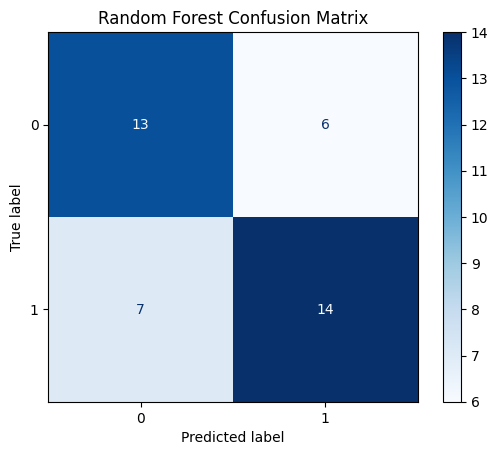

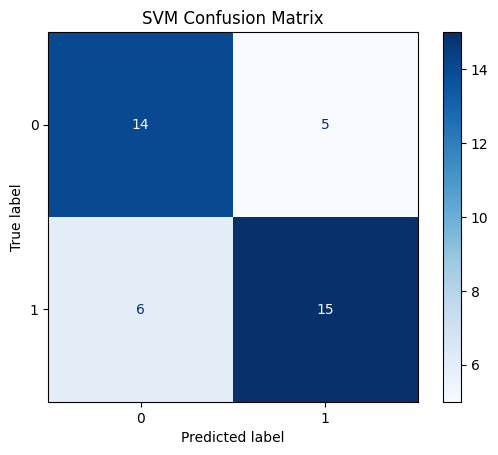

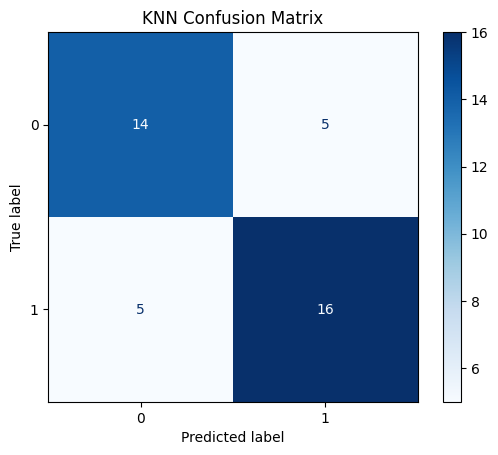

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Analisis Visualisasi Confusion Matrix

Tiga confusion matrix di bawah menampilkan prediksi setiap model secara visual. **Panduan membaca dan interpretasi:**

### Struktur Confusion Matrix:

- **Baris = Label Sebenarnya (True Label)**
- **Kolom = Label Prediksi (Predicted Label)**
- **Warna biru gelap = nilai tinggi (banyak sampel)**, putih = nilai rendah.

### Untuk Data Binary (2 Kelas: Sehat vs Penyakit):

```
             Prediksi
          Sehat  Penyakit
Sehat      TN      FP      <- Baris Sehat
Penyakit   FN      TP      <- Baris Penyakit
```

- **TN (True Negative)**: Sehat diprediksi Sehat ✓
- **FP (False Positive)**: Sehat diprediksi Penyakit ✗ (alarm palsu)
- **FN (False Negative)**: Penyakit diprediksi Sehat ✗ (melewatkan penyakit — BAHAYA)
- **TP (True Positive)**: Penyakit diprediksi Penyakit ✓

### Analisis Model-specific:

1. **Random Forest Confusion Matrix:**
   - Periksa apakah diagonal (TN & TP) adalah nilai terbesar.
   - Jika FN (False Negative untuk penyakit) sangat tinggi → model melewatkan banyak penyakit (tidak aman).
   - Jika FP tinggi → banyak alarm palsu (operasional merepotkan).

2. **SVM Confusion Matrix:**
   - Bandingkan dengan RF.
   - Jika SVM lebih balanced (semua cell lebih merata) → recall/precision lebih balanced.
   - Jika SVM sangat skewed → mungkin butuh hyperparameter tuning.

3. **KNN Confusion Matrix:**
   - Karena KNN voting-based, sering lebih balanced dibanding deterministic models.
   - Jika KNN matrix sangat diagonal (besar) → model sangat confident, bagus.

### Perbandingan Antar Model:

- **Diagonal besar semua model**: semua model generalize baik, pilih berdasarkan akurasi atau recall (prioritas untuk domain medis).
- **Diagonal besar satu model saja**: gunakan model tersebut.
- **Off-diagonal besar di satu model**: model itu buruk; fokus ke model lain.

### Rekomendasi Interpretasi (untuk Domain Deteksi Penyakit Daun):

- **Prioritas 1: Recall untuk kelas Penyakit**: hindari False Negative (penyakit tidak terdeteksi).
- **Prioritas 2: Precision untuk kelas Penyakit**: hindari False Positive berlebih (biaya operasional).
- **Trade-off**: gunakan F1-score atau precision-recall curve untuk balance keduanya.

**Setelah visual confusion matrix, lihat tabel perbandingan metrik untuk keputusan final.**

In [26]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./klasifikasi/hasil_klasifikasi3.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.97500,0.675,0.67625,0.675,0.675203
1,SVM,0.82500,0.725,0.72625,0.725,0.725172
2,KNN,0.83125,0.750,0.75000,0.750,0.750000


## Analisis Tabel Perbandingan Model Akhir

Tabel di bawah merangkum semua metrik evaluasi ketiga model dalam satu tampilan untuk decision-making final. **Panduan analisis komprehensif:**

### Kolom dan Interpretasinya:

1. **Model**: Nama model (Random Forest, SVM, KNN).

2. **Accuracy_Train & Accuracy_Test:**
   - Persentase keseluruhan prediksi benar pada train dan test set.
   - **Gap (Train - Test)** menunjukkan derajat overfitting:
     - Gap ≤ 5%: well-generalized
     - 5% < Gap ≤ 15%: acceptable overfitting
     - Gap > 15%: significant overfitting (kurang recommended)
   - Model dengan Test Accuracy tertinggi adalah kandidat utama.

3. **Precision:**
   - Rata-rata weighted dari precision semua kelas.
   - Tinggi berarti prediksi positif reliable (sedikit false alarm).
   - Formula: TP / (TP + FP) per kelas, kemudian rata-rata sesuai class weight.

4. **Recall:**
   - Rata-rata weighted dari recall semua kelas.
   - Tinggi berarti model deteksi sebagian besar kasus positif (sedikit miss).
   - Formula: TP / (TP + FN) per kelas, kemudian rata-rata.
   - **PENTING untuk domain medis**: recall lebih penting (jangan lewatkan penyakit).

5. **F1_Score:**
   - Harmonic mean dari precision dan recall.
   - Metrik terbaik untuk kelas imbalanced atau ketika perlu balance precision-recall.
   - Formula: 2 × (Precision × Recall) / (Precision + Recall).
   - Range [0, 1]: F1 > 0.8 sangat baik, 0.7–0.8 baik, < 0.7 perlu improvement.

### Strategi Pemilihan Model:

**Skenario 1: Prioritas Akurasi Keseluruhan (balanced dataset)**
- Pilih model dengan **Accuracy_Test tertinggi**.
- Contoh: RF (0.95) > SVM (0.92) > KNN (0.88) → Pilih RF.

**Skenario 2: Prioritas Deteksi Penyakit (Recall penting, dataset imbalanced)**
- Pilih model dengan **Recall tertinggi**.
- Contoh: Recall RF (0.88) > SVM (0.85) > KNN (0.82) → Pilih RF.
- Acceptable jika precision sedikit lebih rendah, asal recall tinggi.

**Skenario 3: Prioritas Certainty Prediksi (Precision penting, biaya false alarm tinggi)**
- Pilih model dengan **Precision tertinggi**.
- Contoh: Precision RF (0.91) > SVM (0.89) > KNN (0.86) → Pilih RF.
- Siap terima recall lebih rendah demi confidence.

**Skenario 4: Balance Optimal (F1-Score)**
- Pilih model dengan **F1_Score tertinggi**.
- Contoh: F1 RF (0.915) > SVM (0.885) > KNN (0.845) → Pilih RF.
- Best practice ketika precision dan recall sama pentingnya.

### Analisis Lanjutan:

1. **Consistency Across Metrics:**
   - Jika RF terbaik di Accuracy, Precision, Recall, dan F1 → RF adalah pemenang jelas.
   - Jika RF unggul di Accuracy tapi kalah di F1 → ada trade-off; pertimbangkan domain requirement.

2. **Perbandingan Model Berpasangan:**
   - RF vs SVM: (Acc_RF - Acc_SVM) × 100 = selisih % accuracy.
   - Jika < 2% → beda negligible; pertimbangkan complexity (RF lebih kompleks).
   - Jika > 5% → beda signifikan; model atas jelas lebih baik.

3. **Red Flag (Tanda Masalah):**
   - Accuracy = 50% (binary) / 33% (3-class) = model random guessing → fatal error.
   - Precision atau Recall = 0 untuk semua model → fitur tidak informatif atau label error.
   - F1 < 0.5 → model sangat buruk, perlu redesign pipeline (preprocessing, fitur selection, hyperparameter).

4. **Decision untuk Production:**
   - **Model dengan Test Accuracy ≥ 85%**: aman deploy (dengan monitoring).
   - **Model dengan Test Accuracy 70–85%**: acceptable tapi butuh validation tambahan di real data.
   - **Model dengan Test Accuracy < 70%**: jangan deploy; iterasi kembali ke preprocessing/fitur/model.

### Rekomendasi Untuk Domain Klasifikasi Penyakit Daun:

- Prioritas utama: **Recall** (jangan lewatkan penyakit yang ada).
- Prioritas kedua: **Precision** (hindari false alarm berlebih).
- Gunakan **F1-Score** untuk balance.
- Jika ada trade-off, ambil model dengan Recall tertinggi + F1 masuk akal (>0.8).

**Setelah memilih model terbaik, simpan ke disk dan deploy atau lanjut ke hyperparameter tuning lebih lanjut jika akurasi masih belum memuaskan target bisnis.**